# Классификация: CC50 > медиана

Бинарная классификация соединений по цитотоксичности (CC50 выше/ниже медианы)

## 1. Загрузка и подготовка данных

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import os
import optuna

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
)

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

os.makedirs('models', exist_ok=True)
RANDOM_STATE = 42

In [9]:
# Загрузка данных
df = pd.read_csv('data_processed.csv')
medians_df = pd.read_csv('medians.csv')

# Получаем медиану CC50
cc50_median = medians_df.loc[medians_df['target'] == 'CC50, mM', 'median'].values[0]
print(f"Медиана CC50: {cc50_median:.4f}")

# Создаём бинарный таргет
df['target'] = (df['CC50, mM'] > cc50_median).astype(int)

# Сохраняем порог
with open('models/cc50_median.txt', 'w') as f:
    f.write(str(cc50_median))

print(f"\nБаланс классов:")
print(df['target'].value_counts())

Медиана CC50: 408.7933

Баланс классов:
target
0    499
1    499
Name: count, dtype: int64


In [10]:
# Подготовка признаков
feature_cols = [col for col in df.columns if col not in ['IC50, mM', 'CC50, mM', 'SI', 'target']]
X = df[feature_cols]
y = df['target']

print(f"Количество признаков: {len(feature_cols)}")
print(f"Размер выборки: {X.shape[0]}")

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Масштабирование для линейных моделей
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Сохраняем scaler
with open('models/scaler_cc50_clf.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Баланс классов в train: {np.bincount(y_train)}")
print(f"Баланс классов в test: {np.bincount(y_test)}")

Количество признаков: 165
Размер выборки: 998
Train: (798, 165), Test: (200, 165)
Баланс классов в train: [399 399]
Баланс классов в test: [100 100]


## 2. Обучение моделей

### Функция для расчёта метрик

In [11]:
def calculate_metrics(y_true, y_pred, y_proba, model_name):
    """Расчёт всех метрик для модели классификации"""
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_proba)
    }

results = []
models_dict = {}

### 2.1. Logistic Regression (бейзлайн)

In [12]:
lr_model = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

y_train_pred_lr = lr_model.predict(X_train_scaled)
y_train_proba_lr = lr_model.predict_proba(X_train_scaled)[:, 1]
y_test_pred_lr = lr_model.predict(X_test_scaled)
y_test_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

results.append(calculate_metrics(y_train, y_train_pred_lr, y_train_proba_lr, 'Logistic Regression (train)'))
results.append(calculate_metrics(y_test, y_test_pred_lr, y_test_proba_lr, 'Logistic Regression (test)'))

models_dict['Logistic Regression'] = {
    'model': lr_model,
    'y_pred': y_test_pred_lr,
    'y_proba': y_test_proba_lr,
    'is_scaled': True
}

print("Logistic Regression результаты:")
print(f"Train ROC-AUC: {results[-2]['ROC-AUC']:.4f}, F1: {results[-2]['F1']:.4f}")
print(f"Test  ROC-AUC: {results[-1]['ROC-AUC']:.4f}, F1: {results[-1]['F1']:.4f}")

Logistic Regression результаты:
Train ROC-AUC: 0.9166, F1: 0.8317
Test  ROC-AUC: 0.8122, F1: 0.7383


### 2.2. Random Forest с GridSearchCV

In [13]:
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    rf_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print(f"Лучшие параметры: {rf_grid.best_params_}")
print(f"Лучший ROC-AUC (CV): {rf_grid.best_score_:.4f}")

rf_best = rf_grid.best_estimator_

y_train_pred_rf = rf_best.predict(X_train)
y_train_proba_rf = rf_best.predict_proba(X_train)[:, 1]
y_test_pred_rf = rf_best.predict(X_test)
y_test_proba_rf = rf_best.predict_proba(X_test)[:, 1]

results.append(calculate_metrics(y_train, y_train_pred_rf, y_train_proba_rf, 'Random Forest (train)'))
results.append(calculate_metrics(y_test, y_test_pred_rf, y_test_proba_rf, 'Random Forest (test)'))

models_dict['Random Forest'] = {
    'model': rf_best,
    'y_pred': y_test_pred_rf,
    'y_proba': y_test_proba_rf,
    'is_scaled': False
}

print(f"\nTrain ROC-AUC: {results[-2]['ROC-AUC']:.4f}, F1: {results[-2]['F1']:.4f}")
print(f"Test  ROC-AUC: {results[-1]['ROC-AUC']:.4f}, F1: {results[-1]['F1']:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Лучшие параметры: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 300}
Лучший ROC-AUC (CV): 0.8441

Train ROC-AUC: 0.9826, F1: 0.9375
Test  ROC-AUC: 0.8608, F1: 0.7826


### 2.3. Gradient Boosting (sklearn) с GridSearchCV

In [14]:
gb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    gb_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(X_train, y_train)

print(f"Лучшие параметры: {gb_grid.best_params_}")
print(f"Лучший ROC-AUC (CV): {gb_grid.best_score_:.4f}")

gb_best = gb_grid.best_estimator_

y_train_pred_gb = gb_best.predict(X_train)
y_train_proba_gb = gb_best.predict_proba(X_train)[:, 1]
y_test_pred_gb = gb_best.predict(X_test)
y_test_proba_gb = gb_best.predict_proba(X_test)[:, 1]

results.append(calculate_metrics(y_train, y_train_pred_gb, y_train_proba_gb, 'Gradient Boosting (train)'))
results.append(calculate_metrics(y_test, y_test_pred_gb, y_test_proba_gb, 'Gradient Boosting (test)'))

models_dict['Gradient Boosting'] = {
    'model': gb_best,
    'y_pred': y_test_pred_gb,
    'y_proba': y_test_proba_gb,
    'is_scaled': False
}

print(f"\nTrain ROC-AUC: {results[-2]['ROC-AUC']:.4f}, F1: {results[-2]['F1']:.4f}")
print(f"Test  ROC-AUC: {results[-1]['ROC-AUC']:.4f}, F1: {results[-1]['F1']:.4f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Лучший ROC-AUC (CV): 0.8434

Train ROC-AUC: 0.9841, F1: 0.9387
Test  ROC-AUC: 0.8423, F1: 0.7512


### 2.4. XGBoost с Optuna

In [15]:
def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=100),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'random_state': RANDOM_STATE
    }
    
    model = XGBClassifier(**params)
    score = cross_val_score(model, X_train, y_train, cv=5, 
                           scoring='roc_auc', n_jobs=-1).mean()
    return score

xgb_study = optuna.create_study(direction='maximize')
xgb_study.optimize(xgb_objective, n_trials=50, show_progress_bar=True)

print(f"Лучшие параметры: {xgb_study.best_params}")
print(f"Лучший ROC-AUC (CV): {xgb_study.best_value:.4f}")

xgb_best = XGBClassifier(**xgb_study.best_params, random_state=RANDOM_STATE)
xgb_best.fit(X_train, y_train)

y_train_pred_xgb = xgb_best.predict(X_train)
y_train_proba_xgb = xgb_best.predict_proba(X_train)[:, 1]
y_test_pred_xgb = xgb_best.predict(X_test)
y_test_proba_xgb = xgb_best.predict_proba(X_test)[:, 1]

results.append(calculate_metrics(y_train, y_train_pred_xgb, y_train_proba_xgb, 'XGBoost (train)'))
results.append(calculate_metrics(y_test, y_test_pred_xgb, y_test_proba_xgb, 'XGBoost (test)'))

models_dict['XGBoost'] = {
    'model': xgb_best,
    'y_pred': y_test_pred_xgb,
    'y_proba': y_test_proba_xgb,
    'is_scaled': False
}

print(f"\nTrain ROC-AUC: {results[-2]['ROC-AUC']:.4f}, F1: {results[-2]['F1']:.4f}")
print(f"Test  ROC-AUC: {results[-1]['ROC-AUC']:.4f}, F1: {results[-1]['F1']:.4f}")

Best trial: 26. Best value: 0.845657: 100%|██████████| 50/50 [01:20<00:00,  1.61s/it]


Лучшие параметры: {'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.03782635716050846, 'subsample': 0.9522760355597889, 'colsample_bytree': 0.7917537398569016, 'min_child_weight': 4}
Лучший ROC-AUC (CV): 0.8457

Train ROC-AUC: 0.9833, F1: 0.9366
Test  ROC-AUC: 0.8539, F1: 0.7656


### 2.5. LightGBM с Optuna

In [16]:
def lgbm_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'verbose': -1,
        'random_state': RANDOM_STATE
    }
    
    model = LGBMClassifier(**params)
    score = cross_val_score(model, X_train, y_train, cv=5, 
                           scoring='roc_auc', n_jobs=-1).mean()
    return score

lgbm_study = optuna.create_study(direction='maximize')
lgbm_study.optimize(lgbm_objective, n_trials=100, show_progress_bar=True)

print(f"Лучшие параметры: {lgbm_study.best_params}")
print(f"Лучший ROC-AUC (CV): {lgbm_study.best_value:.4f}")

lgbm_best = LGBMClassifier(**lgbm_study.best_params, verbose=-1, random_state=RANDOM_STATE)
lgbm_best.fit(X_train, y_train)

y_train_pred_lgbm = lgbm_best.predict(X_train)
y_train_proba_lgbm = lgbm_best.predict_proba(X_train)[:, 1]
y_test_pred_lgbm = lgbm_best.predict(X_test)
y_test_proba_lgbm = lgbm_best.predict_proba(X_test)[:, 1]

results.append(calculate_metrics(y_train, y_train_pred_lgbm, y_train_proba_lgbm, 'LightGBM (train)'))
results.append(calculate_metrics(y_test, y_test_pred_lgbm, y_test_proba_lgbm, 'LightGBM (test)'))

models_dict['LightGBM'] = {
    'model': lgbm_best,
    'y_pred': y_test_pred_lgbm,
    'y_proba': y_test_proba_lgbm,
    'is_scaled': False
}

print(f"\nTrain ROC-AUC: {results[-2]['ROC-AUC']:.4f}, F1: {results[-2]['F1']:.4f}")
print(f"Test  ROC-AUC: {results[-1]['ROC-AUC']:.4f}, F1: {results[-1]['F1']:.4f}")

Best trial: 4. Best value: 0.84728: 100%|██████████| 100/100 [01:13<00:00,  1.36it/s]


Лучшие параметры: {'n_estimators': 247, 'max_depth': 3, 'learning_rate': 0.023014292501794216, 'subsample': 0.8766450972991211, 'colsample_bytree': 0.7334472485506326, 'num_leaves': 51, 'min_child_samples': 5}
Лучший ROC-AUC (CV): 0.8473

Train ROC-AUC: 0.9542, F1: 0.8744
Test  ROC-AUC: 0.8293, F1: 0.7451


### 2.6. Калибровка вероятностей

Калибруем модели, которые могут плохо оценивать вероятности (Logistic Regression и Random Forest)

In [17]:
# Калибровка Logistic Regression
lr_calibrated = CalibratedClassifierCV(lr_model, cv='prefit', method='isotonic')
lr_calibrated.fit(X_train_scaled, y_train)

y_test_proba_lr_cal = lr_calibrated.predict_proba(X_test_scaled)[:, 1]
y_test_pred_lr_cal = (y_test_proba_lr_cal > 0.5).astype(int)

results.append(calculate_metrics(y_test, y_test_pred_lr_cal, y_test_proba_lr_cal, 'Logistic Regression Calibrated'))

models_dict['Logistic Regression Calibrated'] = {
    'model': lr_calibrated,
    'y_pred': y_test_pred_lr_cal,
    'y_proba': y_test_proba_lr_cal,
    'is_scaled': True
}

print(f"Logistic Regression Calibrated: ROC-AUC = {results[-1]['ROC-AUC']:.4f}")

# Калибровка Random Forest
rf_calibrated = CalibratedClassifierCV(rf_best, cv='prefit', method='isotonic')
rf_calibrated.fit(X_train, y_train)

y_test_proba_rf_cal = rf_calibrated.predict_proba(X_test)[:, 1]
y_test_pred_rf_cal = (y_test_proba_rf_cal > 0.5).astype(int)

results.append(calculate_metrics(y_test, y_test_pred_rf_cal, y_test_proba_rf_cal, 'Random Forest Calibrated'))

models_dict['Random Forest Calibrated'] = {
    'model': rf_calibrated,
    'y_pred': y_test_pred_rf_cal,
    'y_proba': y_test_proba_rf_cal,
    'is_scaled': False
}

print(f"Random Forest Calibrated: ROC-AUC = {results[-1]['ROC-AUC']:.4f}")

Logistic Regression Calibrated: ROC-AUC = 0.8089
Random Forest Calibrated: ROC-AUC = 0.8546


## 3. Сравнение моделей

In [18]:
results_df = pd.DataFrame(results)
print("\nВсе результаты:")
print(results_df.to_string(index=False))

test_results = results_df[results_df['Model'].str.contains('test|Calibrated')].copy()
test_results['Model'] = test_results['Model'].str.replace(' \(test\)', '')
test_results = test_results.sort_values('ROC-AUC', ascending=False)

print("Рейтинг моделей по ROC-AUC на тестовой выборке:")
for i, row in test_results.iterrows():
    print(f"{row['Model']:<35} ROC-AUC={row['ROC-AUC']:.4f}, F1={row['F1']:.4f}, Acc={row['Accuracy']:.4f}")


Все результаты:
                         Model  Accuracy  Precision   Recall       F1  ROC-AUC
   Logistic Regression (train)  0.827068   0.809976 0.854637 0.831707 0.916602
    Logistic Regression (test)  0.720000   0.692982 0.790000 0.738318 0.812200
         Random Forest (train)  0.937343   0.935162 0.939850 0.937500 0.982632
          Random Forest (test)  0.775000   0.757009 0.810000 0.782609 0.860800
     Gradient Boosting (train)  0.938596   0.937500 0.939850 0.938673 0.984080
      Gradient Boosting (test)  0.745000   0.733333 0.770000 0.751220 0.842300
               XGBoost (train)  0.936090   0.928571 0.944862 0.936646 0.983336
                XGBoost (test)  0.755000   0.733945 0.800000 0.765550 0.853900
              LightGBM (train)  0.869674   0.843823 0.907268 0.874396 0.954199
               LightGBM (test)  0.740000   0.730769 0.760000 0.745098 0.829300
Logistic Regression Calibrated  0.725000   0.695652 0.800000 0.744186 0.808900
      Random Forest Calibrated  0.7

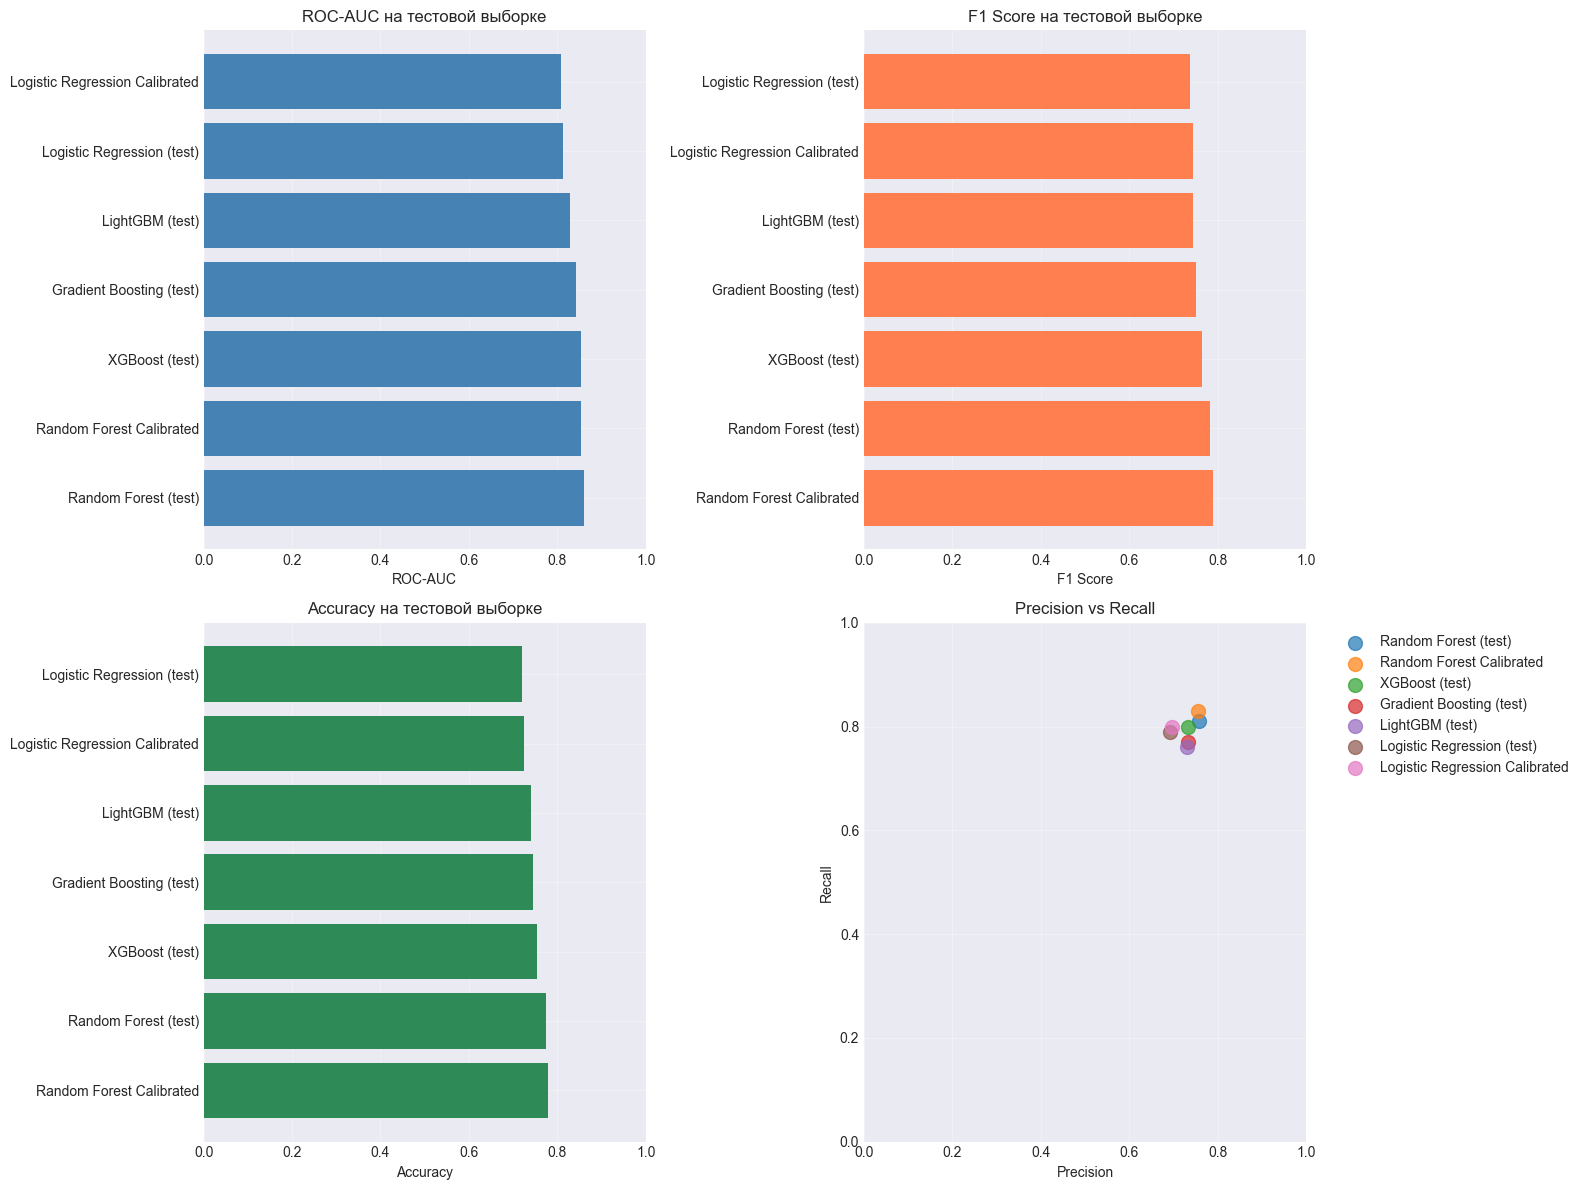

In [19]:
# Визуализация сравнения
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ROC-AUC
test_results_sorted = test_results.sort_values('ROC-AUC', ascending=False)
axes[0, 0].barh(test_results_sorted['Model'], test_results_sorted['ROC-AUC'], color='steelblue')
axes[0, 0].set_xlabel('ROC-AUC')
axes[0, 0].set_title('ROC-AUC на тестовой выборке')
axes[0, 0].set_xlim(0, 1)
axes[0, 0].grid(True, alpha=0.3)

# F1 Score
test_results_sorted = test_results.sort_values('F1', ascending=False)
axes[0, 1].barh(test_results_sorted['Model'], test_results_sorted['F1'], color='coral')
axes[0, 1].set_xlabel('F1 Score')
axes[0, 1].set_title('F1 Score на тестовой выборке')
axes[0, 1].set_xlim(0, 1)
axes[0, 1].grid(True, alpha=0.3)

# Accuracy
test_results_sorted = test_results.sort_values('Accuracy', ascending=False)
axes[1, 0].barh(test_results_sorted['Model'], test_results_sorted['Accuracy'], color='seagreen')
axes[1, 0].set_xlabel('Accuracy')
axes[1, 0].set_title('Accuracy на тестовой выборке')
axes[1, 0].set_xlim(0, 1)
axes[1, 0].grid(True, alpha=0.3)

# Precision vs Recall
for _, row in test_results.iterrows():
    axes[1, 1].scatter(row['Precision'], row['Recall'], s=100, label=row['Model'], alpha=0.7)
axes[1, 1].set_xlabel('Precision')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].set_title('Precision vs Recall')
axes[1, 1].set_xlim(0, 1)
axes[1, 1].set_ylim(0, 1)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 4. Детальный анализ лучшей модели

In [20]:
# Определяем лучшую модель
best_model_name_raw = test_results.iloc[0]['Model']
best_model_name = best_model_name_raw.replace(' (test)', '').strip()

best_model_info = models_dict[best_model_name]
best_model = best_model_info['model']
y_pred_best = best_model_info['y_pred']
y_proba_best = best_model_info['y_proba']

print(f"Лучшая модель: {best_model_name}")
print(f"\nМетрики на тестовой выборке:")
print(f"Accuracy: {test_results.iloc[0]['Accuracy']:.4f}")
print(f"Precision: {test_results.iloc[0]['Precision']:.4f}")
print(f"Recall: {test_results.iloc[0]['Recall']:.4f}")
print(f"F1: {test_results.iloc[0]['F1']:.4f}")
print(f"ROC-AUC: {test_results.iloc[0]['ROC-AUC']:.4f}")
print(classification_report(y_test, y_pred_best, digits=4))

Лучшая модель: Random Forest

Метрики на тестовой выборке:
Accuracy: 0.7750
Precision: 0.7570
Recall: 0.8100
F1: 0.7826
ROC-AUC: 0.8608
              precision    recall  f1-score   support

           0     0.7957    0.7400    0.7668       100
           1     0.7570    0.8100    0.7826       100

    accuracy                         0.7750       200
   macro avg     0.7764    0.7750    0.7747       200
weighted avg     0.7764    0.7750    0.7747       200



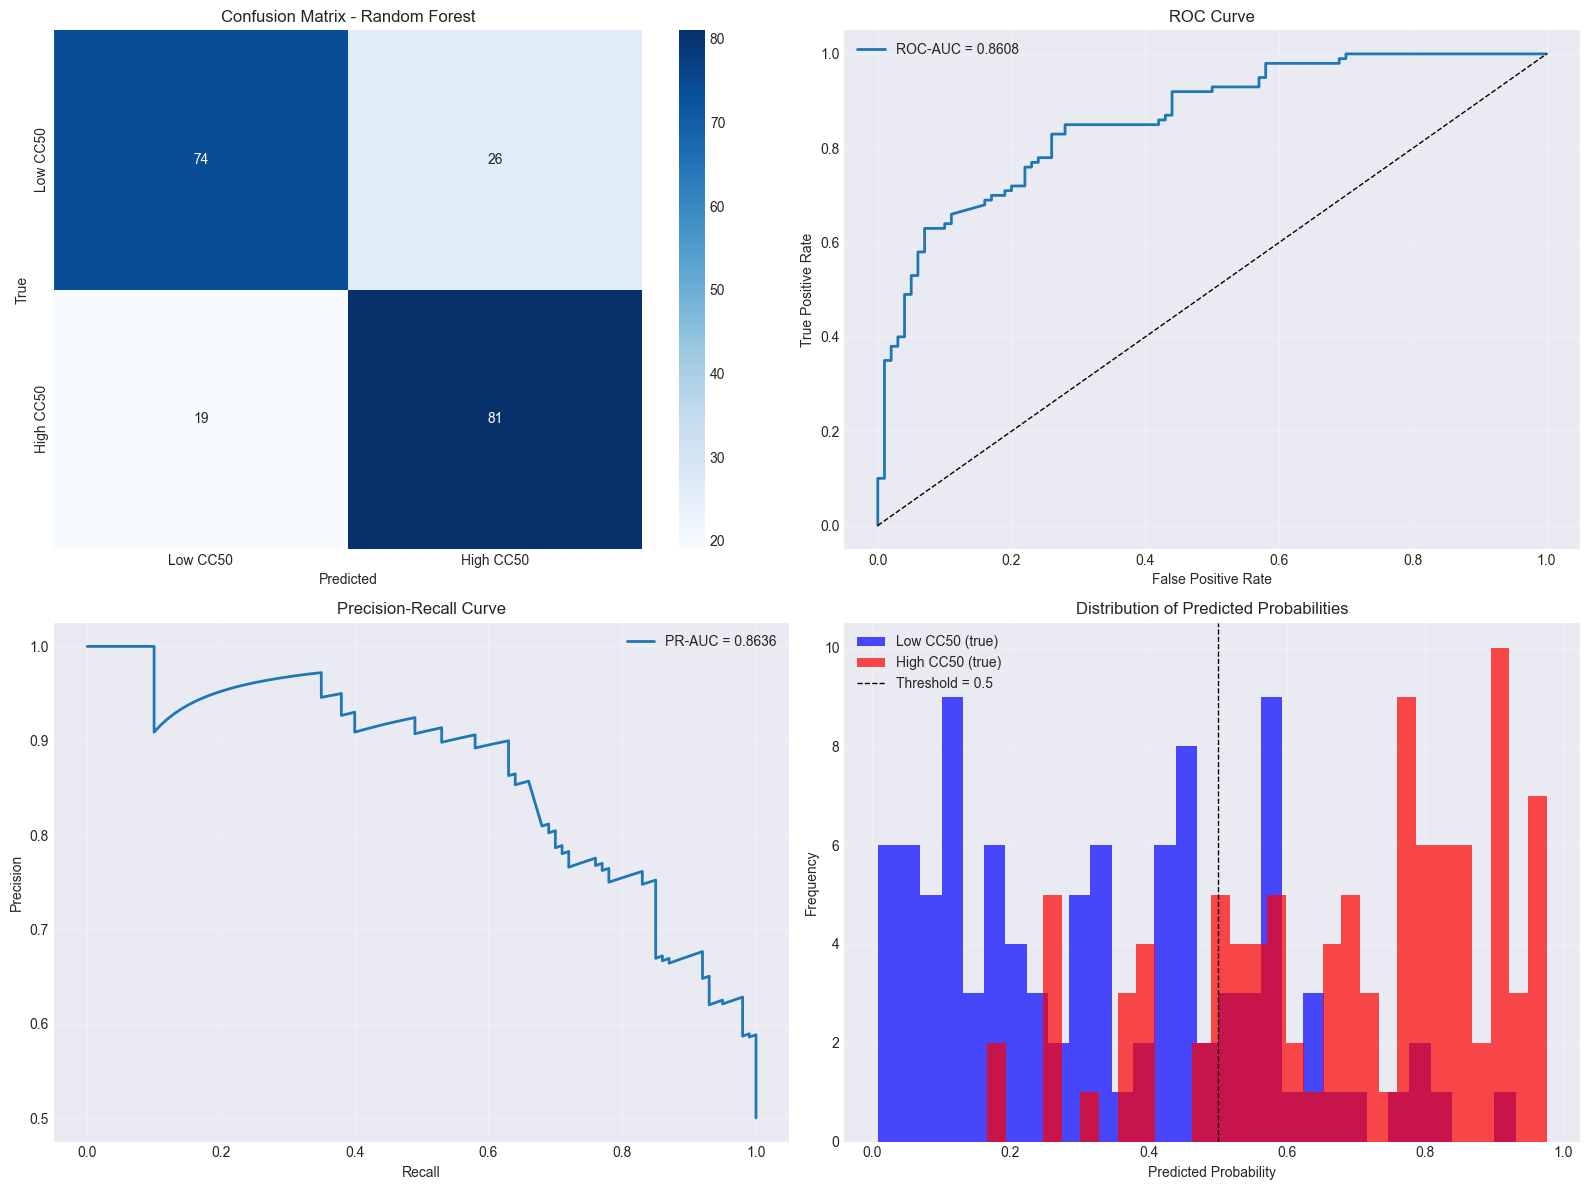

In [21]:
# Визуализация метрик лучшей модели
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0], 
            xticklabels=['Low CC50', 'High CC50'], yticklabels=['Low CC50', 'High CC50'])
axes[0, 0].set_title(f'Confusion Matrix - {best_model_name}')
axes[0, 0].set_ylabel('True')
axes[0, 0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_best)
roc_auc = auc(fpr, tpr)
axes[0, 1].plot(fpr, tpr, lw=2, label=f'ROC-AUC = {roc_auc:.4f}')
axes[0, 1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba_best)
pr_auc = auc(recall, precision)
axes[1, 0].plot(recall, precision, lw=2, label=f'PR-AUC = {pr_auc:.4f}')
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Precision-Recall Curve')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Распределение предсказанных вероятностей
axes[1, 1].hist(y_proba_best[y_test == 0], bins=30, alpha=0.7, label='Low CC50 (true)', color='blue')
axes[1, 1].hist(y_proba_best[y_test == 1], bins=30, alpha=0.7, label='High CC50 (true)', color='red')
axes[1, 1].axvline(0.5, color='black', linestyle='--', lw=1, label='Threshold = 0.5')
axes[1, 1].set_xlabel('Predicted Probability')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Predicted Probabilities')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Важность признаков

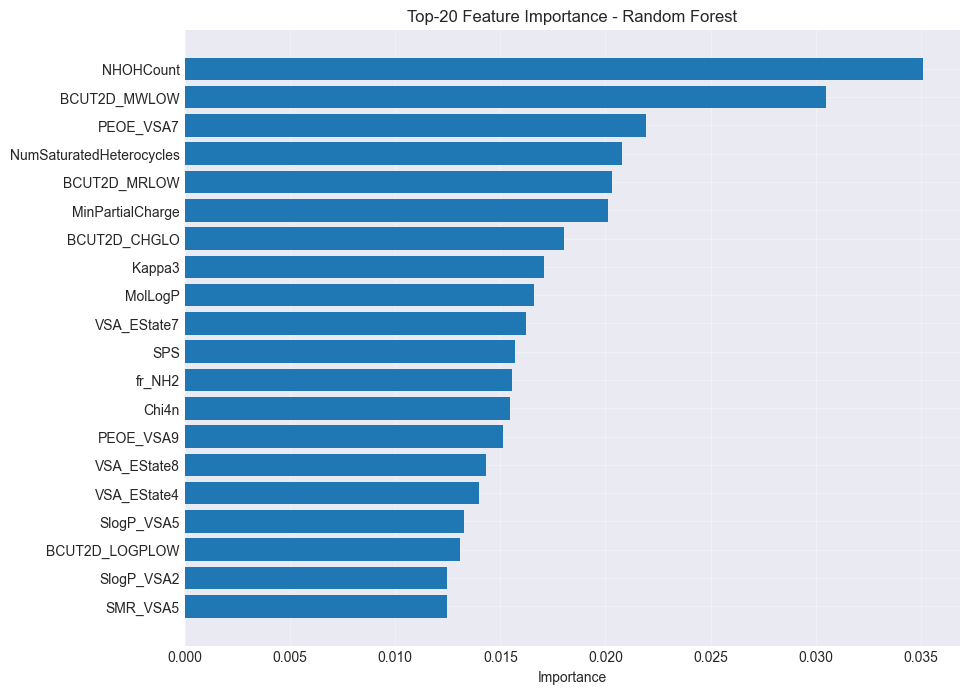


Топ-10 важных признаков:
                 Feature  Importance
               NHOHCount    0.035085
            BCUT2D_MWLOW    0.030463
               PEOE_VSA7    0.021915
NumSaturatedHeterocycles    0.020801
            BCUT2D_MRLOW    0.020331
        MinPartialCharge    0.020128
            BCUT2D_CHGLO    0.018044
                  Kappa3    0.017098
                 MolLogP    0.016579
             VSA_EState7    0.016230


In [22]:
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance')
plt.title(f'Top-20 Feature Importance - {best_model_name}')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.show()

print("\nТоп-10 важных признаков:")
print(feature_importance.head(10).to_string(index=False))

## 6. Сохранение лучшей модели

In [23]:
metrics_to_save = test_results.iloc[0].to_dict()
metrics_to_save['Model'] = best_model_name

model_info = {
    'model': best_model,
    'model_name': best_model_name,
    'features': feature_cols,
    'scaler': scaler,
    'threshold': cc50_median,
    'is_scaled': best_model_info['is_scaled'],
    'metrics': metrics_to_save
}

with open('models/best_cc50_classification.pkl', 'wb') as f:
    pickle.dump(model_info, f)

print(f"Лучшая модель сохранена: models/best_cc50_classification.pkl")
print(f"\nМодель: {best_model_name}")
print(f"Метрики: ROC-AUC={test_results.iloc[0]['ROC-AUC']:.4f}, F1={test_results.iloc[0]['F1']:.4f}")

Лучшая модель сохранена: models/best_cc50_classification.pkl

Модель: Random Forest
Метрики: ROC-AUC=0.8608, F1=0.7826


## 7. Выводы и рекомендации

### Рекомендации по улучшению

1. **Генерация новых признаков**
   - Создание взаимодействий между важными дескрипторами
   - Доменные знания о SAR

2. **Ансамблирование**
   - Стекинг лучших моделей (XGBoost + LightGBM + RF)
   - Голосование между калиброванными моделями

### Заключение

Лучшие модели показывают сопоставимые результаты. Можно использовать стекинг для максимального качества